In [165]:
import pandas as pd 
import numpy as np

In [166]:
data = pd.read_csv("fraud_detection_dataset.csv")

In [167]:
data.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Amount,Merchant_Category,Transaction_Type,Customer_Age,Account_Tenure,Num_Transactions_Last_24H,Location_Match,Fraud
0,TXN0000001,1102,2025-01-14 20:00:00,1928.96,Fuel,POS,31.0,0.0,7.0,1,No
1,TXN0000002,1435,2025-01-08 06:00:00,1651.05,Grocery,Online,44.0,7.0,5.0,1,No
2,TXN0000003,1860,2025-01-28 08:00:00,1324.14,Healthcare,POS,46.0,14.0,5.0,1,No
3,TXN0000004,1270,2025-01-19 08:00:00,1240.01,Healthcare,ATM,56.0,9.0,7.0,1,No
4,TXN0000005,1106,2025-01-06 05:00:00,1122.22,Grocery,Online,56.0,2.0,6.0,1,No


In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             5000 non-null   object 
 1   Customer_ID                5000 non-null   int64  
 2   Transaction_DateTime       5000 non-null   object 
 3   Transaction_Amount         4750 non-null   float64
 4   Merchant_Category          4850 non-null   object 
 5   Transaction_Type           5000 non-null   object 
 6   Customer_Age               4800 non-null   float64
 7   Account_Tenure             4700 non-null   float64
 8   Num_Transactions_Last_24H  4750 non-null   float64
 9   Location_Match             5000 non-null   int64  
 10  Fraud                      5000 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 429.8+ KB


In [169]:
 data.describe()

,Customer_ID,Transaction_Amount,Customer_Age,Account_Tenure,Num_Transactions_Last_24H,Location_Match
count,5000.000000,4750.000000,4800.000000,4700.000000,4750.000000,5000.000000
mean,1505.701200,1193.692676,43.413542,6.994681,5.106947,0.899400
std,290.836902,502.846003,14.909871,4.330781,2.567500,0.300828
min,1000.000000,50.000000,18.000000,0.000000,1.000000,0.000000
25%,1253.000000,842.000000,31.000000,3.000000,3.000000,1.000000
50%,1510.000000,1197.495000,43.000000,7.000000,5.000000,1.000000
75%,1761.000000,1534.707500,56.000000,11.000000,7.000000,1.000000
max,1999.000000,2977.810000,69.000000,14.000000,9.000000,1.000000


In [170]:
data.isnull().sum()

Transaction_ID                 0
Customer_ID                    0
Transaction_DateTime           0
Transaction_Amount           250
Merchant_Category            150
Transaction_Type               0
Customer_Age                 200
Account_Tenure               300
Num_Transactions_Last_24H    250
Location_Match                 0
Fraud                          0
dtype: int64

In [171]:
data = data.dropna()

In [172]:
data = data.drop(columns=["Transaction_ID", "Customer_ID"])

In [173]:
data.head()

,Transaction_DateTime,Transaction_Amount,Merchant_Category,Transaction_Type,Customer_Age,Account_Tenure,Num_Transactions_Last_24H,Location_Match,Fraud
0,2025-01-14 20:00:00,1928.96,Fuel,POS,31.0,0.0,7.0,1,No
1,2025-01-08 06:00:00,1651.05,Grocery,Online,44.0,7.0,5.0,1,No
2,2025-01-28 08:00:00,1324.14,Healthcare,POS,46.0,14.0,5.0,1,No
3,2025-01-19 08:00:00,1240.01,Healthcare,ATM,56.0,9.0,7.0,1,No
4,2025-01-06 05:00:00,1122.22,Grocery,Online,56.0,2.0,6.0,1,No


In [174]:
X = data.drop('Fraud', axis=1)
y = data['Fraud']

In [175]:
data['Fraud'].value_counts()

Fraud
No     3815
Yes     130
Name: count, dtype: int64

In [176]:
import matplotlib.pyplot as plt 
import seaborn as sns 

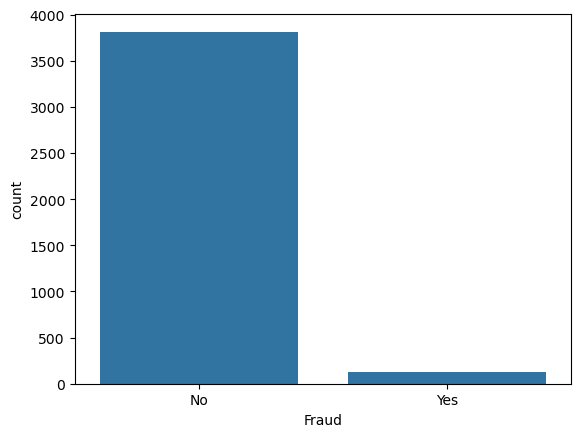

In [177]:
sns.countplot(x= 'Fraud', data=data)
plt.show()

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [179]:
y = y.replace({'No':0, 'Yes':1})

/var/folders/tf/9zhrb62s1sd6nn7l9g2y8wsr0000gn/T/ipykernel_17973/3207231589.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'No':0, 'Yes':1})


In [180]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [181]:
print(y_train.value_counts())

Fraud
0    3056
1     100
Name: count, dtype: int64


In [182]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [183]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
from datetime import datetime

datetime_columns = ['date_column1', 'date_column2']   #column names

def extract_datetime_features(data, datetime_cols):
    data_copy = data.copy()
    for col in datetime_cols:
        try:
           
            data_copy[col] = pd.to_datetime(data_copy[col])
            
            
            data_copy[f'{col}_year'] = data_copy[col].dt.year
            data_copy[f'{col}_month'] = data_copy[col].dt.month
            data_copy[f'{col}_day'] = data_copy[col].dt.day
            data_copy[f'{col}_hour'] = data_copy[col].dt.hour
            
            
            data_copy = data_copy.drop(col, axis=1)
        except Exception as e:
            print(f"Could not process column {col}: {e}")
            # Skip this column if it can't be converted
    return data_copy


X_train_transformed = extract_datetime_features(X_train, datetime_columns)


categorical_columns = X_train_transformed.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
        ],
        remainder='passthrough'  
    )
    X_train_transformed = preprocessor.fit_transform(X_train_transformed)
    
model.fit(X_train_transformed, y_train)

Could not process column date_column1: 'date_column1'
Could not process column date_column2: 'date_column2'


RandomForestClassifier(random_state=42)

In [184]:
X_test_transformed = extract_datetime_features(X_test, datetime_columns)

X_test_transformed = preprocessor.transform(X_test_transformed)

Could not process column date_column1: 'date_column1'
Could not process column date_column2: 'date_column2'


In [185]:
y_pred = model.predict(X_test_transformed)

In [186]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [187]:
print(confusion_matrix(y_test, y_pred))

[[759   0]
 [ 30   0]]


In [188]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       759
           1       0.00      0.00      0.00        30

    accuracy                           0.96       789
   macro avg       0.48      0.50      0.49       789
weighted avg       0.93      0.96      0.94       789



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [189]:
y_prob = model.predict_proba(X_test_transformed)[:,1]

In [190]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.643719806763285


In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

In [194]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


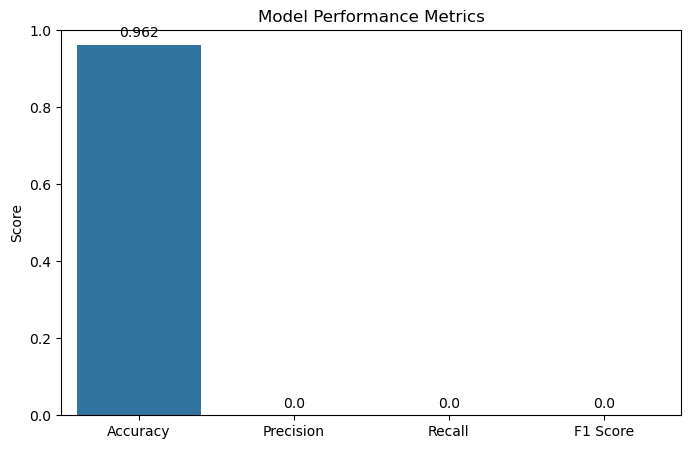

In [195]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
sns.barplot(x=metrics, y=values)

plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.ylabel("Score")

for i,v in enumerate(values):
    plt.text(i, v+0.02, round(v,3), ha='center')

plt.show()

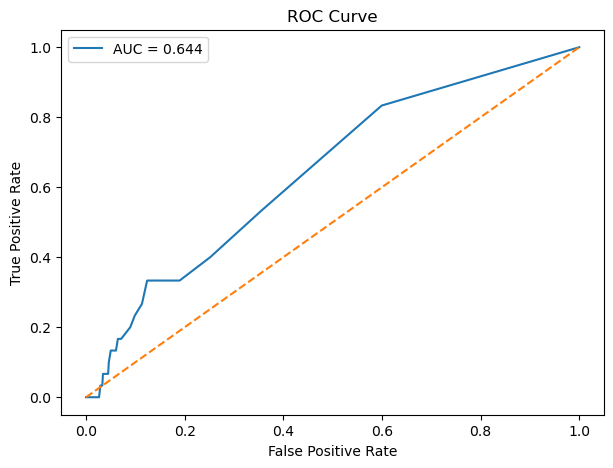

In [191]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [196]:
import pandas as pd

results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred
results["Fraud_Probability"] = y_prob

In [198]:
results.to_csv("fraud_predictions.csv", index=False)